## 0. Setup dataset
tải folder "tom_and_jerry" trên kaggle sau đó để file ipynb và folder "tom_and_jerry" vào 1 folder sau đó run all.

## 1. Cài đặt thư viện

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Đọc ảnh và gắn label cho dataset

In [2]:
dataset_path = "tom_and_jerry"
classes = [
    "jerry",
    "tom",
    "tom_jerry_0",
    "tom_jerry_1"
]
images = []
labels = []

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    for file in tqdm(os.listdir(folder), desc=cls):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is None:
            continue
        images.append(img)
        labels.append(label)

print(f"Số ảnh: {len(images)}")
print(f"Số nhãn: {len(labels)}")

tom_jerry_1: 100%|██████████| 780/780 [00:02<00:00, 261.81it/s]

Số ảnh: 5478
Số nhãn: 5478


## 3. Kiểm tra data

Kích thước ảnh đầu tiên: (720, 1280, 3)
Label đầu tiên: 0


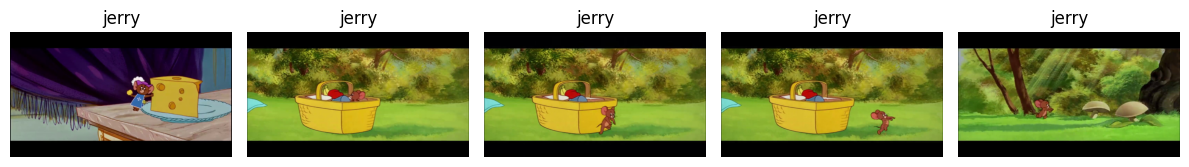

In [3]:
print("Kích thước ảnh đầu tiên:", images[0].shape)
print("Label đầu tiên:", labels[0])
plt.figure(figsize=(12,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Loại bỏ viền đen cho ảnh

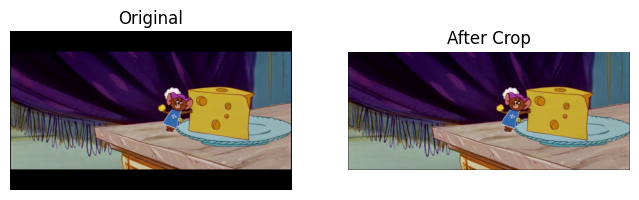

In [4]:
def remove_black_border(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]

sample = images[0]
crop = remove_black_border(sample)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("After Crop")
plt.axis("off")
plt.show()

## 5. Feature extraction: HOG + RGB histogram

In [5]:
def extract_feature(img):
    img = remove_black_border(img)
    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm="L2-Hys"
    )
    hist = []
    for c in range(3):
        h = cv2.calcHist([img], [c], None, [32], [0,256])
        h = cv2.normalize(h, h).flatten()
        hist.extend(h)
    feature = np.concatenate([hog_feature, hist])
    return feature

feature = extract_feature(images[0])
print("Số chiều feature:", len(feature))

Số chiều feature: 8196


Ta có ảnh sau khi được resize là 128x128 và số cell mỗi chiều là 128/8=16 cells. Số block mỗi chiều là 16-2+1=15 blocks. Số features là 2x2x9=36. Vậy nên HOG đã tạo ra 15x15x36=8100 features. Còn RGB ta có c in range 3 và mỗi kênh có 32 bins vậy số features là 96. Tổng hợp HOG và RGB ta được 8196.

## 6. Chia tập train/test

In [6]:
X = []
y = []
for img, label in tqdm(zip(images, labels), total=len(images), desc="Extracting features"):
    feature = extract_feature(img)
    X.append(feature)
    y.append(label)
X = np.array(X)
y = np.array(y)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Extracting features: 100%|██████████| 5478/5478 [01:14<00:00, 73.69it/s] 


Shape of X: (5478, 8196)
Shape of y: (5478,)
Train: (4382, 8196)
Test : (1096, 8196)


## 7. Chuẩn hóa data

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 8. Dùng SVM để train model

In [8]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    decision_function_shape="ovo",
    random_state=42
)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print(svm_model.decision_function_shape)

ovo


## 9. Tính Accuracy, Precision, Recall, F1-score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy: 0.8084
Precision : 0.8135
Recall    : 0.8084
F1-score  : 0.8080
              precision    recall  f1-score   support

       jerry       0.84      0.71      0.77       248
         tom       0.82      0.88      0.85       386
 tom_jerry_0       0.73      0.82      0.77       306
 tom_jerry_1       0.90      0.78      0.83       156

    accuracy                           0.81      1096
   macro avg       0.83      0.79      0.81      1096
weighted avg       0.81      0.81      0.81      1096



## 10. Confusion Matrix

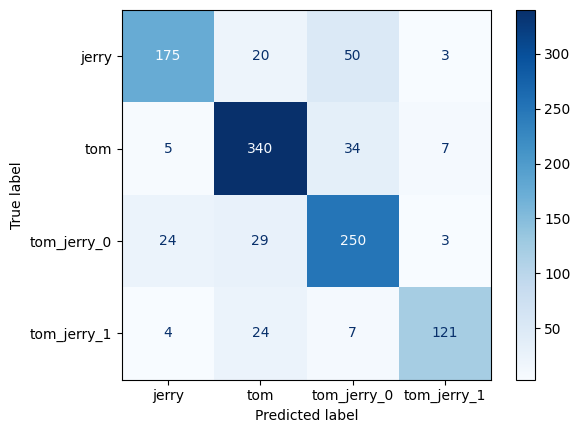

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
disp.plot(cmap="Blues")
plt.show()